# TB Diagnostic Gap & Point-of-Care Test Market-Fit Analysis

**Author:** Maddy | MS by Research, Biomedical Engineering, IIT Madras
**Domain context:** This analysis is built on top of my thesis work developing a
polyclonal antibody-based lateral flow immunoassay (LFA) for TB diagnostics
(Ag85B antigen, gold nanoparticle-based, IIT Madras).

## Problem statement
Every year, millions of active TB cases are estimated by WHO but never
formally notified/detected by health systems — the **"missing cases" gap**.
This gap is largest in countries with weak diagnostic infrastructure
(low lab budgets, low rapid-test coverage), which is precisely the setting
where low-cost, equipment-free point-of-care assays (like an LFA) have the
most impact.

This notebook:
1. Builds a country-year panel from WHO Global TB Programme open data
   (burden estimates, notifications, treatment outcomes, budgets).
2. Engineers a **diagnostic gap** metric and diagnostic-infrastructure features.
3. Trains an ML model to explain/predict case detection rate from
   infrastructure & financing features (with SHAP interpretation).
4. Clusters countries into **diagnostic-infrastructure archetypes**.
5. Produces an **LFA Priority Score** to rank countries as go-to-market
   targets for low-resource point-of-care TB diagnostics.

## Data sources (WHO Global TB Programme, https://extranet.who.int/tme)
- `estimates` — TB burden estimates (incidence, mortality, HIV-TB, CDR)
- `notifications` — case notifications, rapid diagnostic test (RDx) usage
- `outcomes` — treatment outcomes (success rate, cohort sizes)
- `budget` — national TB program budgets & financing sources

> Note: treatment-outcome and budget indicators lag the current year
> (patients are followed for the duration of treatment, and budget data
> collection lags reporting), so this notebook uses **2021** as the primary
> cross-sectional scoring year — the most recent year with acceptable
> coverage across all four datasets — while using the full 2000–2024 panel
> for trend analysis.


In [1]:
# If running in Google Colab, upload the 4 WHO CSV files when prompted.
# Files needed (download from https://www.who.int/teams/global-tuberculosis-programme/data):
#   - TB burden estimates            (ds=estimates)
#   - Case notifications             (ds=notifications)
#   - Treatment outcomes             (ds=outcomes)
#   - Budgets                        (ds=budget)

import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Upload the 4 WHO TB CSV files (burden, notifications, outcomes, budget):")
    uploaded = files.upload()
    DATA_DIR = "."
else:
    DATA_DIR = "./data"  # local folder with the CSVs


In [2]:
!pip install -q shap plotly --upgrade 2>/dev/null
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import shap
import plotly.express as px
import glob, warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)


## 1. Load raw WHO datasets

The cell below auto-detects the uploaded/local filenames by matching on
keywords, so it works whether files keep their WHO-default names or your
downloaded names (e.g. `TB_burden_countries_....csv`).

In [3]:
def find_file(keyword):
    matches = [f for f in glob.glob(f"{DATA_DIR}/*.csv") if keyword.lower() in f.lower()]
    if not matches:
        raise FileNotFoundError(f"No CSV found matching '{keyword}' in {DATA_DIR}")
    return matches[0]

burden_path   = find_file("burden") if glob.glob(f"{DATA_DIR}/*burden*") else find_file("estimates")
notif_path    = find_file("notif")
outcomes_path = find_file("outcome")
budget_path   = find_file("budget")

burden   = pd.read_csv(burden_path)
notif    = pd.read_csv(notif_path)
outcomes = pd.read_csv(outcomes_path)
budget   = pd.read_csv(budget_path)

print("Burden:   ", burden.shape)
print("Notif:    ", notif.shape)
print("Outcomes: ", outcomes.shape)
print("Budget:   ", budget.shape)
burden.head(3)


Burden:    (5347, 50)
Notif:     (9567, 216)
Outcomes:  (6399, 73)
Budget:    (1720, 43)


,country,iso2,iso3,iso_numeric,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,e_inc_num,e_inc_num_lo,e_inc_num_hi,e_tbhiv_prct,e_tbhiv_prct_lo,e_tbhiv_prct_hi,e_inc_tbhiv_100k,e_inc_tbhiv_100k_lo,e_inc_tbhiv_100k_hi,e_inc_tbhiv_num,e_inc_tbhiv_num_lo,e_inc_tbhiv_num_hi,e_mort_exc_tbhiv_100k,e_mort_exc_tbhiv_100k_lo,e_mort_exc_tbhiv_100k_hi,e_mort_exc_tbhiv_num,e_mort_exc_tbhiv_num_lo,e_mort_exc_tbhiv_num_hi,e_mort_tbhiv_100k,e_mort_tbhiv_100k_lo,e_mort_tbhiv_100k_hi,e_mort_tbhiv_num,e_mort_tbhiv_num_lo,e_mort_tbhiv_num_hi,e_mort_100k,e_mort_100k_lo,e_mort_100k_hi,e_mort_num,e_mort_num_lo,e_mort_num_hi,cfr,cfr_lo,cfr_hi,cfr_pct,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20130323,148.0,46.0,1510.0,30000.0,9200.0,305000.0,0.02,NaN,NaN,0.03,0.0,0.07,5.0,0.0,15.0,50.0,32.0,70.0,10000.0,6500.0,14000.0,0.02,0.0,0.05,3.0,0.0,9.0,50.0,32.0,70.0,10000.0,6500.0,14000.0,0.34,0.19,0.50,34.0,19.0,50.0,35.0,24.0,2.3,77.0
1,Afghanistan,AF,AFG,4,EMR,2001,20284311,175.0,66.0,1320.0,35000.0,13000.0,267000.0,0.01,NaN,NaN,0.03,0.0,0.08,5.0,0.0,16.0,55.0,37.0,76.0,11000.0,7600.0,15000.0,0.02,0.0,0.05,3.0,0.0,9.0,55.0,37.0,76.0,11000.0,7600.0,15000.0,0.32,0.20,0.46,32.0,20.0,46.0,50.0,29.0,3.8,76.0
2,Afghanistan,AF,AFG,4,EMR,2002,21378110,197.0,83.0,1140.0,42000.0,18000.0,245000.0,0.01,NaN,NaN,0.03,0.0,0.08,6.0,0.0,18.0,59.0,41.0,80.0,13000.0,8700.0,17000.0,0.02,0.0,0.05,3.0,0.0,10.0,59.0,41.0,80.0,13000.0,8700.0,17000.0,0.30,0.19,0.42,30.0,19.0,42.0,65.0,33.0,5.6,78.0


## 2. Exploratory data check

Quick look at missingness and the overall shape of estimated TB burden
globally before we merge anything.

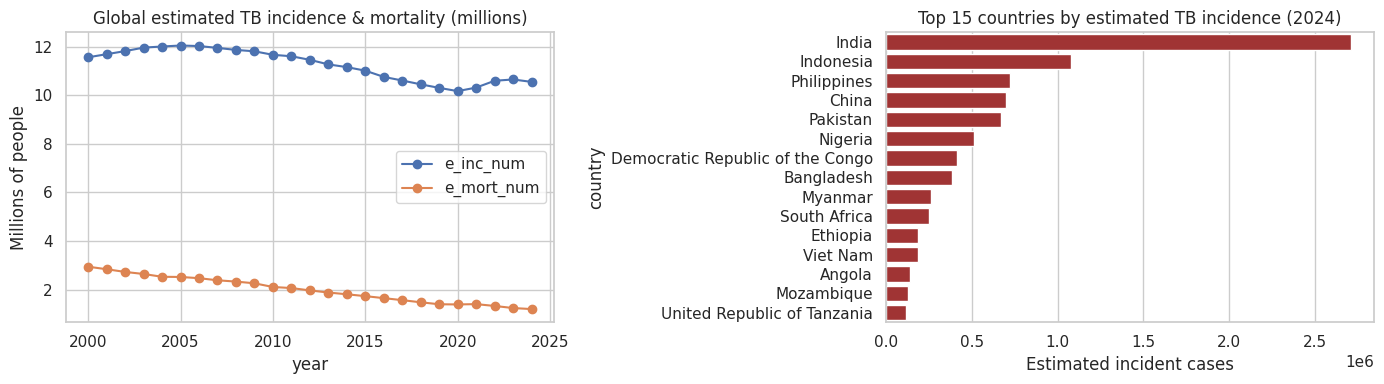

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

global_trend = burden.groupby("year")[["e_inc_num", "e_mort_num"]].sum(min_count=1) / 1e6
global_trend.plot(ax=ax[0], marker="o")
ax[0].set_title("Global estimated TB incidence & mortality (millions)")
ax[0].set_ylabel("Millions of people")

top15 = burden[burden.year == burden.year.max()].nlargest(15, "e_inc_num")
sns.barplot(data=top15, y="country", x="e_inc_num", ax=ax[1], color="firebrick")
ax[1].set_title(f"Top 15 countries by estimated TB incidence ({burden.year.max()})")
ax[1].set_xlabel("Estimated incident cases")
plt.tight_layout()
plt.show()


## 3. Merge & feature engineering

Building the core analytical features:

- **`diagnostic_gap_num` / `diagnostic_gap_pct`** — estimated incident cases
  minus notified cases (the "missing cases"), as a count and as a % of
  estimated incidence.
- **`case_detection_rate`** — WHO's own CDR estimate where available.
- **`rdx_coverage_pct`** — share of notified cases diagnosed via a rapid
  diagnostic test (e.g. GeneXpert) — a proxy for modern diagnostic access.
- **`budget_lab_per100k` / `lab_budget_share_pct`** — lab budget normalized
  per capita and as a share of the total TB program budget.
- **`donor_dependency_pct`** — share of financing from Global Fund/USAID —
  a proxy for program fragility/sustainability.
- **`treatment_success_pct`** — WHO cohort treatment success rate.
- **`lfa_priority_score`** — composite, transparent score (weighted, min-max
  normalized) combining diagnostic gap, incidence rate, RDx coverage gap,
  and lab budget gap — used to rank countries as LFA deployment targets.

In [5]:
KEY = ["iso3", "country", "g_whoregion", "year"]

burden_s = burden[KEY + [
    "e_pop_num", "e_inc_100k", "e_inc_num", "e_inc_num_lo", "e_inc_num_hi",
    "e_tbhiv_prct", "e_mort_100k", "e_mort_num", "cfr_pct", "c_cdr",
]].copy()

notif_s = notif[KEY + ["c_newinc", "newinc_rdx", "notif_foreign"]].copy()

outcomes_s = outcomes[KEY + ["c_new_tsr", "newrel_coh", "mdr_coh", "mdr_succ"]].copy()

budget_s = budget[KEY + [
    "budget_lab", "budget_tot", "budget_staff", "cf_tot",
    "cf_tot_domestic", "cf_tot_gf", "cf_tot_usaid",
]].copy()

df = (burden_s
      .merge(notif_s, on=KEY, how="left")
      .merge(outcomes_s, on=KEY, how="left")
      .merge(budget_s, on=KEY, how="left"))

print("Merged panel shape:", df.shape)


Merged panel shape: (5347, 28)


In [6]:
# --- Feature engineering ---
df["diagnostic_gap_num"] = (df["e_inc_num"] - df["c_newinc"]).clip(lower=0)
df["diagnostic_gap_pct"] = np.where(
    df["e_inc_num"] > 0, df["diagnostic_gap_num"] / df["e_inc_num"], np.nan
).clip(0, 1)

df["case_detection_rate"] = df["c_cdr"].fillna(100 * (1 - df["diagnostic_gap_pct"]))

df["rdx_coverage_pct"] = np.where(
    df["c_newinc"] > 0, 100 * df["newinc_rdx"] / df["c_newinc"], np.nan
)

df["budget_lab_per100k"] = np.where(
    df["e_pop_num"] > 0, 1e5 * df["budget_lab"] / df["e_pop_num"], np.nan
)
df["budget_tot_per100k"] = np.where(
    df["e_pop_num"] > 0, 1e5 * df["budget_tot"] / df["e_pop_num"], np.nan
)
df["lab_budget_share_pct"] = np.where(
    df["budget_tot"] > 0, 100 * df["budget_lab"] / df["budget_tot"], np.nan
)

df["donor_dependency_pct"] = np.where(
    df["cf_tot"] > 0,
    100 * (df["cf_tot_gf"].fillna(0) + df["cf_tot_usaid"].fillna(0)) / df["cf_tot"],
    np.nan,
)

df["treatment_success_pct"] = df["c_new_tsr"]
df["hiv_tb_burden_pct"] = df["e_tbhiv_prct"]

df.to_csv("tb_master_panel.csv", index=False)
df.tail(2)


,iso3,country,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_num,e_inc_num_lo,e_inc_num_hi,e_tbhiv_prct,e_mort_100k,e_mort_num,cfr_pct,c_cdr,c_newinc,newinc_rdx,notif_foreign,c_new_tsr,newrel_coh,mdr_coh,mdr_succ,budget_lab,budget_tot,budget_staff,cf_tot,cf_tot_domestic,cf_tot_gf,cf_tot_usaid,diagnostic_gap_num,diagnostic_gap_pct,case_detection_rate,rdx_coverage_pct,budget_lab_per100k,budget_tot_per100k,lab_budget_share_pct,donor_dependency_pct,treatment_success_pct,hiv_tb_burden_pct
5345,ZWE,Zimbabwe,AFR,2023,16340822,209.0,34000.0,23000.0,46000.0,62.0,54.0,8900.0,27.0,56.0,19207.0,18096.0,0.0,91.0,19163.0,NaN,NaN,4840102.0,17359487.0,2164756.0,16153683.0,1000000.0,5774773.0,9378910.0,14793.0,0.435088,56.0,94.215651,29619.697222,106233.866326,27.881596,93.809461,91.0,62.0
5346,ZWE,Zimbabwe,AFR,2024,16634364,203.0,34000.0,21000.0,45000.0,62.0,49.0,8200.0,25.0,60.0,20286.0,NaN,0.0,NaN,NaN,NaN,NaN,25072529.0,57500712.0,1977244.0,13178590.0,1000000.0,10241036.0,1937554.0,13714.0,0.403353,60.0,NaN,150727.307639,345674.243993,43.603858,92.411935,NaN,62.0


## 4. Cross-sectional scoring table (2021)

Using 2021 as the reference year — the most recent year with acceptable
coverage across notification, outcome, and budget data (later years suffer
from treatment-outcome and budget reporting lag).

In [7]:
SCORE_YEAR = 2021
score_df = df[df["year"] == SCORE_YEAR].copy()

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

score_df["lfa_priority_score"] = (
    0.40 * minmax(score_df["diagnostic_gap_pct"].fillna(0))
    + 0.30 * minmax(score_df["e_inc_100k"].fillna(0))
    + 0.20 * (1 - minmax(score_df["rdx_coverage_pct"].fillna(0)))
    + 0.10 * (1 - minmax(score_df["budget_lab_per100k"].fillna(0)))
)

print("Missingness in key features, scoring year", SCORE_YEAR, ":")
print(score_df[[
    "diagnostic_gap_pct", "rdx_coverage_pct", "budget_lab_per100k",
    "treatment_success_pct", "lfa_priority_score"
]].isna().mean().round(3))

score_df.to_csv("tb_scored_2021.csv", index=False)
score_df[["country", "diagnostic_gap_pct", "e_inc_100k", "rdx_coverage_pct",
          "lfa_priority_score"]].sort_values("lfa_priority_score", ascending=False).head(10)


Missingness in key features, scoring year 2021 :
diagnostic_gap_pct       0.070
rdx_coverage_pct         0.233
budget_lab_per100k       0.521
treatment_success_pct    0.130
lfa_priority_score       0.000
dtype: float64


,country,diagnostic_gap_pct,e_inc_100k,rdx_coverage_pct,lfa_priority_score
3741,Papua New Guinea,0.534306,622.0,NaN,0.854870
3136,Mongolia,0.806500,421.0,48.357327,0.786283
1461,Djibouti,0.591136,392.0,NaN,0.782254
3256,Myanmar,0.657394,353.0,NaN,0.781132
4495,South Sudan,0.527892,339.0,NaN,0.720662
2711,Lesotho,0.679286,606.0,84.788419,0.717785
146,Angola,0.518039,371.0,NaN,0.711797
1411,Democratic Republic of the Congo,0.459929,401.0,9.397037,0.696660
871,Cambodia,0.540660,279.0,NaN,0.689587
971,Central African Republic,0.425391,446.0,19.657990,0.681244


## 5. EDA on engineered features

Correlation structure and the countries with the largest absolute
diagnostic gaps.

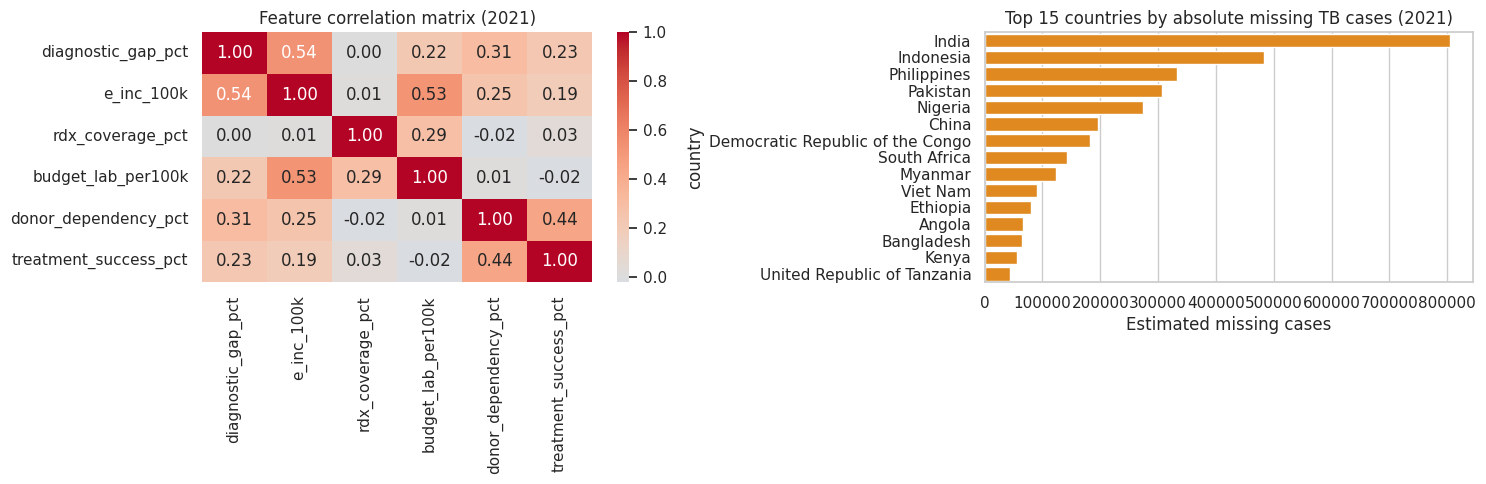

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

feat_cols = ["diagnostic_gap_pct", "e_inc_100k", "rdx_coverage_pct",
             "budget_lab_per100k", "donor_dependency_pct", "treatment_success_pct"]
corr = score_df[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Feature correlation matrix (2021)")

top_gap = score_df.nlargest(15, "diagnostic_gap_num")
sns.barplot(data=top_gap, y="country", x="diagnostic_gap_num", ax=ax[1], color="darkorange")
ax[1].set_title("Top 15 countries by absolute missing TB cases (2021)")
ax[1].set_xlabel("Estimated missing cases")
plt.tight_layout()
plt.show()


## 6. Model 1 — Predicting case detection rate

A single cross-sectional year gives too few complete-data countries (~90)
for a robust model, so instead we **pool 2015–2022** into one training set
(a pooled cross-section — each country-year is a row; not a true panel
model, so results describe association across country-years, not causal
within-country effects). This gives ~5-6x more training rows and lets us
add `g_whoregion` as a control, since detection-system maturity varies
systematically by region.

A Random Forest regression predicts **case detection rate** from
diagnostic-infrastructure and financing features. This isn't meant to be a
production forecasting model — it's used to **explain** which factors most
associate with detection gaps (via feature importance / SHAP) and to
sanity-check the priority score.

In [9]:
POOL_YEARS = list(range(2015, 2023))
pool_df = df[df["year"].isin(POOL_YEARS)].copy()

model_feats_num = [
    "e_inc_100k", "e_tbhiv_prct", "rdx_coverage_pct", "budget_lab_per100k",
    "budget_tot_per100k", "donor_dependency_pct", "cfr_pct",
]
target = "case_detection_rate"

pool_df = pool_df.dropna(subset=[target] + model_feats_num)
region_dummies = pd.get_dummies(pool_df["g_whoregion"], prefix="region", drop_first=True)
pool_df = pd.concat([pool_df, region_dummies], axis=1)

model_feats = model_feats_num + list(region_dummies.columns)
print(f"Pooled country-year rows with complete data for modeling: {len(pool_df)}")
print(f"Years pooled: {POOL_YEARS}")

X = pool_df[model_feats]
y = pool_df[target]

# Group-aware split: hold out entire countries, not just rows, to avoid leakage
# (same country appearing in both train and test across different years)
from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=pool_df["iso3"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestRegressor(n_estimators=500, max_depth=8, min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print(f"R^2:  {r2_score(y_test, pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, pred):.2f} percentage points")
print(f"Held-out countries: {pool_df.iloc[test_idx]['iso3'].nunique()}")


Pooled country-year rows with complete data for modeling: 420
Years pooled: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


R^2:  0.499
MAE:  8.91 percentage points
Held-out countries: 23


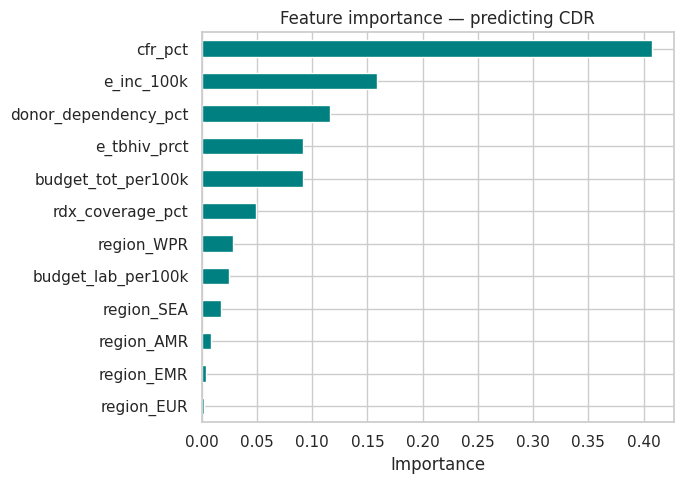

In [10]:
importances = pd.Series(rf.feature_importances_, index=model_feats).sort_values()
importances.plot(kind="barh", figsize=(7, 5), color="teal", title="Feature importance — predicting CDR")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### SHAP interpretation

SHAP values show not just *which* features matter, but *how* — e.g.
whether higher lab budgets push predicted detection rate up or down for
specific countries.

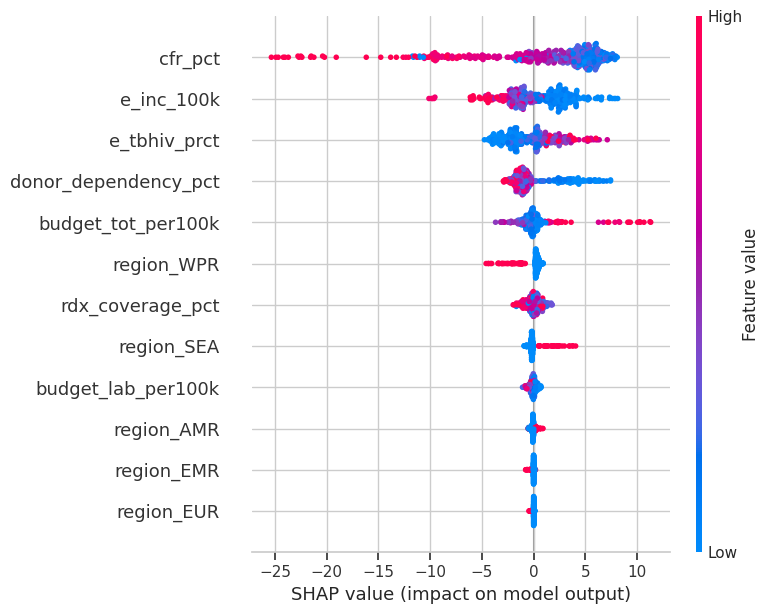

In [11]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.show()


## 7. Model 2 — Diagnostic-infrastructure archetypes (K-Means)

Segmenting countries into clusters based on burden + infrastructure
features, so we can label archetypes like *"high-burden / low-infrastructure"*
(prime LFA target) vs *"low-burden / well-resourced"* (low priority).

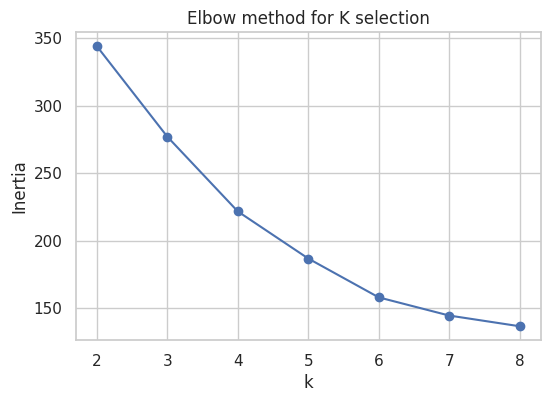

In [12]:
cluster_feats = ["e_inc_100k", "diagnostic_gap_pct", "rdx_coverage_pct",
                 "budget_lab_per100k", "treatment_success_pct"]
cluster_df = score_df.dropna(subset=cluster_feats).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_feats])

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow method for K selection")
plt.show()


In [13]:
K = 4  # chosen from elbow plot — adjust after inspecting the plot above
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

profile = cluster_df.groupby("cluster")[cluster_feats].mean().round(1)
profile["n_countries"] = cluster_df["cluster"].value_counts()
profile


,e_inc_100k,diagnostic_gap_pct,rdx_coverage_pct,budget_lab_per100k,treatment_success_pct,n_countries
cluster,,,,,,
0,63.5,0.3,46.6,13143.5,63.5,11
1,472.1,0.5,71.7,93533.5,83.9,9
2,156.9,0.4,29.4,14659.5,87.7,38
3,111.4,0.4,81.8,23187.1,86.6,31


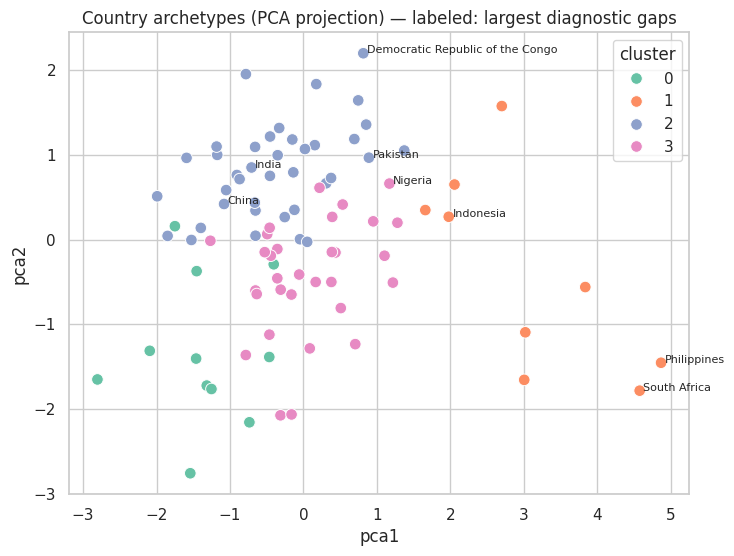

In [14]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
cluster_df["pca1"], cluster_df["pca2"] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x="pca1", y="pca2", hue="cluster", palette="Set2", s=70)
for _, row in cluster_df.nlargest(8, "diagnostic_gap_num").iterrows():
    plt.text(row["pca1"] + 0.05, row["pca2"], row["country"], fontsize=8)
plt.title("Country archetypes (PCA projection) — labeled: largest diagnostic gaps")
plt.show()


**Interpreting clusters:** inspect the `profile` table above — label
each cluster (e.g. "High burden / low RDx coverage", "Well-resourced / low
burden", "Donor-dependent / mid-burden") based on the mean feature values,
and use that narrative directly in your CV project write-up or interview
talking points.

## 8. LFA Priority Score — target market ranking

Combining everything into the final ranked list of countries that would
benefit most from a low-cost, equipment-free point-of-care TB LFA.

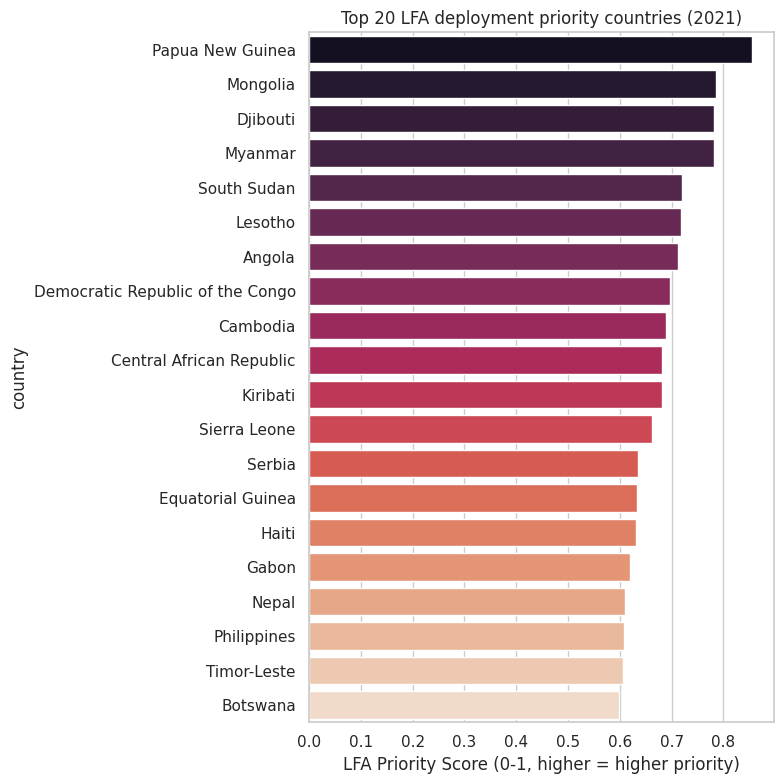

,country,g_whoregion,diagnostic_gap_pct,e_inc_100k,rdx_coverage_pct,lfa_priority_score
3741,Papua New Guinea,WPR,0.534306,622.0,NaN,0.854870
3136,Mongolia,WPR,0.806500,421.0,48.357327,0.786283
1461,Djibouti,EMR,0.591136,392.0,NaN,0.782254
3256,Myanmar,SEA,0.657394,353.0,NaN,0.781132
4495,South Sudan,AFR,0.527892,339.0,NaN,0.720662
2711,Lesotho,AFR,0.679286,606.0,84.788419,0.717785
146,Angola,AFR,0.518039,371.0,NaN,0.711797
1411,Democratic Republic of the Congo,AFR,0.459929,401.0,9.397037,0.696660
871,Cambodia,WPR,0.540660,279.0,NaN,0.689587
971,Central African Republic,AFR,0.425391,446.0,19.657990,0.681244


In [15]:
top20 = score_df.nlargest(20, "lfa_priority_score")

plt.figure(figsize=(8, 8))
sns.barplot(data=top20, y="country", x="lfa_priority_score", palette="rocket")
plt.title(f"Top 20 LFA deployment priority countries ({SCORE_YEAR})")
plt.xlabel("LFA Priority Score (0-1, higher = higher priority)")
plt.tight_layout()
plt.show()

top20[["country", "g_whoregion", "diagnostic_gap_pct", "e_inc_100k",
       "rdx_coverage_pct", "lfa_priority_score"]]


In [16]:
fig = px.choropleth(
    score_df,
    locations="iso3",
    color="lfa_priority_score",
    hover_name="country",
    hover_data=["diagnostic_gap_pct", "e_inc_100k", "rdx_coverage_pct"],
    color_continuous_scale="OrRd",
    title=f"LFA Deployment Priority Score by Country ({SCORE_YEAR})",
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()


## 9. Save outputs

Persist the scored table and the priority ranking for reuse in a dashboard
or for citing specific figures in a resume/portfolio write-up.

In [17]:
score_df.to_csv("tb_scored_2021_full.csv", index=False)
top20.to_csv("tb_top20_lfa_targets.csv", index=False)
print("Saved: tb_scored_2021_full.csv, tb_top20_lfa_targets.csv")


Saved: tb_scored_2021_full.csv, tb_top20_lfa_targets.csv


## 10. Key findings & limitations (fill in after running)

**Findings (template — replace with your actual numbers once run):**
- The diagnostic gap model achieves R² = _____ on held-out countries.
- The strongest predictors of case detection rate are: _____, _____.
- Cluster _____ represents "high-burden / low-infrastructure" countries —
  these are the top LFA deployment candidates.
- The top 5 LFA priority countries are: _____.

**Limitations:**
- WHO estimates carry uncertainty intervals (`e_inc_num_lo/hi`) not
  incorporated into the model — a natural extension is a
  probabilistic/Bayesian treatment.
- Budget and RDx-coverage data have substantial missingness (~50%),
  concentrated in smaller/lower-reporting-capacity countries — exactly the
  countries most relevant to this analysis, so results should be read as
  directional, not definitive.
- The LFA Priority Score weights are a transparent, interpretable heuristic,
  not a fitted/optimized model — appropriate for a first-pass market
  screening tool, but should be validated against in-country program data
  before real deployment decisions.

**Connection to my thesis work:** This analysis provides a data-driven,
country-level target list to complement the technical validation of my
Ag85B-based gold nanoparticle LFA (LOD 0.6 ng/mL, checkerboard ELISA upper
limit 2.5 µg/mL) — pairing diagnostic performance with an evidence-based
go-to-market/deployment prioritization.
